## Notebook Explanation

This notebook demonstrates various clustering algorithms and evaluates their performance using silhouette scores. It also visualizes the clustering results and compares the silhouette scores visually.

In [9]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.svm import SVC
from sklearn.decomposition import PCA

This cell imports the necessary libraries for clustering (DBSCAN, AgglomerativeClustering, KMeans), evaluation (silhouette_score), classification (SVC), and dimensionality reduction (PCA).

In [ ]:
pca = PCA(n_components=2, random_state=42)      #کاهش ابعاد به 2 بعد
vectors_2d = pca.fit_transform(text1_vectors)

Here, Principal Component Analysis (PCA) is applied to reduce the dimensionality of the `text1_vectors` to 2 dimensions for visualization purposes.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)       #k-means model
labels_kmeans = kmeans.fit_predict(text1_vectors)

a:\apps\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


This cell performs KMeans clustering with 3 clusters on the `text1_vectors`.

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=2)         # dbscan
labels_dbscan = dbscan.fit_predict(text1_vectors)

This cell applies DBSCAN clustering with specified `eps` and `min_samples` parameters.

In [ ]:
agglo = AgglomerativeClustering(n_clusters=3)       #agglomerative clustering
labels_agglo = agglo.fit_predict(text1_vectors)

This cell performs Agglomerative Clustering with 3 clusters.

In [ ]:
def safe_silhouette(X, labels):     #  X: normalized text
    unique_labels = set(labels)

    if len(unique_labels) < 2:
        print("invalid labelling")
        return -1

    if -1 in unique_labels:     #removing invalid labels
        mask = (labels != -1)

        if len(set(labels[mask])) < 2:
            print("just one cluster")
            return -1

        score = silhouette_score(X[mask], labels[mask])
    else:
        score = silhouette_score(X, labels)     #default silhouette

    return score

This helper function `safe_silhouette` calculates the silhouette score. It handles cases where there are too few unique labels or when there are noise points (labeled -1 by DBSCAN).

In [ ]:
sil_kmeans = safe_silhouette(text1_vectors, labels_kmeans)
sil_dbscan = safe_silhouette(text1_vectors, labels_dbscan)
sil_agglo = safe_silhouette(text1_vectors, labels_agglo)

print(f"Silhouette KMeans: {sil_kmeans:.3f}")
print(f"Silhouette DBSCAN: {sil_dbscan:.3f}")
print(f"Silhouette Agglo: {sil_agglo:.3f}")

invalid labelling
Silhouette KMeans: 0.181
Silhouette DBSCAN: -1.000
Silhouette Agglo: 0.203


This cell calculates the silhouette scores for KMeans, DBSCAN, and Agglomerative Clustering using the `safe_silhouette` function and prints the results.

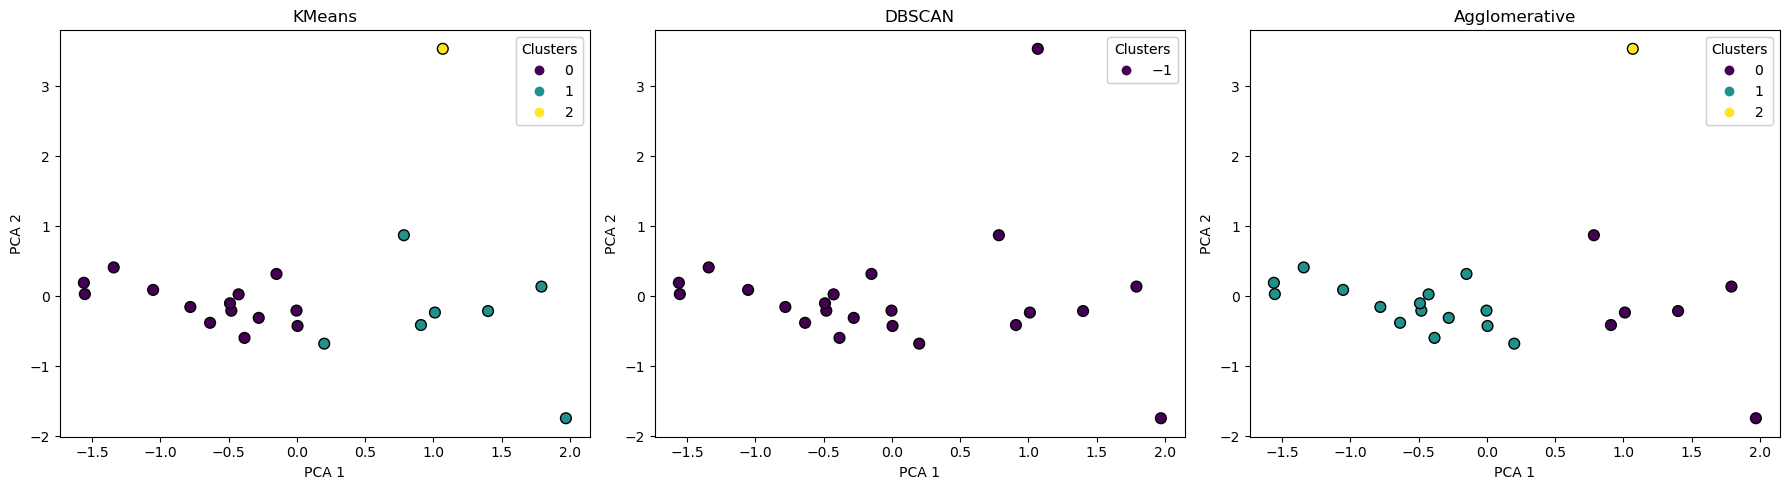

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['KMeans', 'DBSCAN', 'Agglomerative']
labels_list = [labels_kmeans, labels_dbscan, labels_agglo]

for ax, title, labels in zip(axes, titles, labels_list):
    scatter = ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=labels, cmap='viridis', edgecolor='k', s=60)
    ax.set_title(title)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
    ax.add_artist(legend1)

plt.tight_layout()
plt.show()

This cell visualizes the clustering results for KMeans, DBSCAN, and Agglomerative Clustering in a 2D PCA-reduced space. Each plot shows the clusters colored differently.

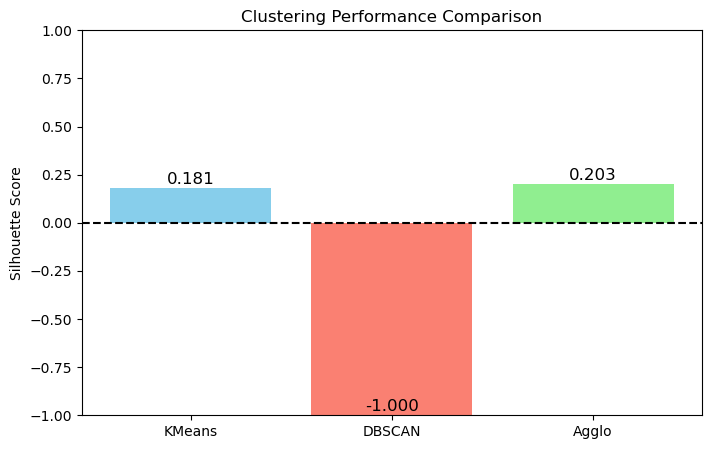

In [ ]:
models = ['KMeans', 'DBSCAN', 'Agglo']
scores = [sil_kmeans, sil_dbscan, sil_agglo]
colors = ['skyblue', 'salmon', 'lightgreen']

plt.figure(figsize=(8,5))
bars = plt.bar(models, scores, color=colors)
plt.ylim(-1, 1)
plt.ylabel('Silhouette Score')
plt.title('Clustering Performance Comparison')

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.3f}', ha='center', fontsize=12)

plt.axhline(y=0, color='black', linestyle='--')
plt.show()

This cell generates a bar chart comparing the silhouette scores of the different clustering models, making it easy to see which model performed best according to this metric.

## New Dataset

create a new synthetic dataset and apply the same clustering algorithms to it to see how they perform.

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# Generate a new synthetic dataset with 4 distinct clusters
text2_vectors, true_labels = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

print(f"Shape of new dataset: {text2_vectors.shape}")

Shape of new dataset: (300, 2)


Now, we'll apply PCA to reduce the new dataset to 2 dimensions for visualization, just like before.

In [17]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA

pca_new = PCA(n_components=2, random_state=42)
vectors_2d_new = pca_new.fit_transform(text2_vectors)

Applying KMeans clustering to the new dataset. We will set `n_clusters` to 4, as we know the true number of clusters in this synthetic data.

In [13]:
kmeans_new = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans_new = kmeans_new.fit_predict(text2_vectors)

Applying DBSCAN clustering to the new dataset. We will use `eps` and `min_samples` that might be suitable for this dataset, or experiment with them if needed.

In [14]:
dbscan_new = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan_new = dbscan_new.fit_predict(text2_vectors)

Applying Agglomerative Clustering to the new dataset, again with 4 clusters.

In [15]:
agglo_new = AgglomerativeClustering(n_clusters=4)
labels_agglo_new = agglo_new.fit_predict(text2_vectors)

## calculate the silhouette scores for the clustering results on this new dataset. We'll use the `safe_silhouette` function defined earlier.

In [19]:
from sklearn.metrics import silhouette_score

def safe_silhouette(X, labels):
    unique_labels = set(labels)

    if len(unique_labels) < 2:
        print("invalid labelling")
        return -1

    if -1 in unique_labels:
        mask = (labels != -1)

        if len(set(labels[mask])) < 2:
            print("just one cluster")
            return -1

        score = silhouette_score(X[mask], labels[mask])
    else:
        score = silhouette_score(X, labels)

    return score

sil_kmeans_new = safe_silhouette(text2_vectors, labels_kmeans_new)
sil_dbscan_new = safe_silhouette(text2_vectors, labels_dbscan_new)
sil_agglo_new = safe_silhouette(text2_vectors, labels_agglo_new)

print(f"Silhouette KMeans (new data): {sil_kmeans_new:.3f}")
print(f"Silhouette DBSCAN (new data): {sil_dbscan_new:.3f}")
print(f"Silhouette Agglo (new data): {sil_agglo_new:.3f}")

Silhouette KMeans (new data): 0.834
Silhouette DBSCAN (new data): 0.620
Silhouette Agglo (new data): 0.834


# Visualization

 ## Visualizing the clustering results for KMeans, DBSCAN, and Agglomerative Clustering on the new, 2D PCA-reduced synthetic dataset.

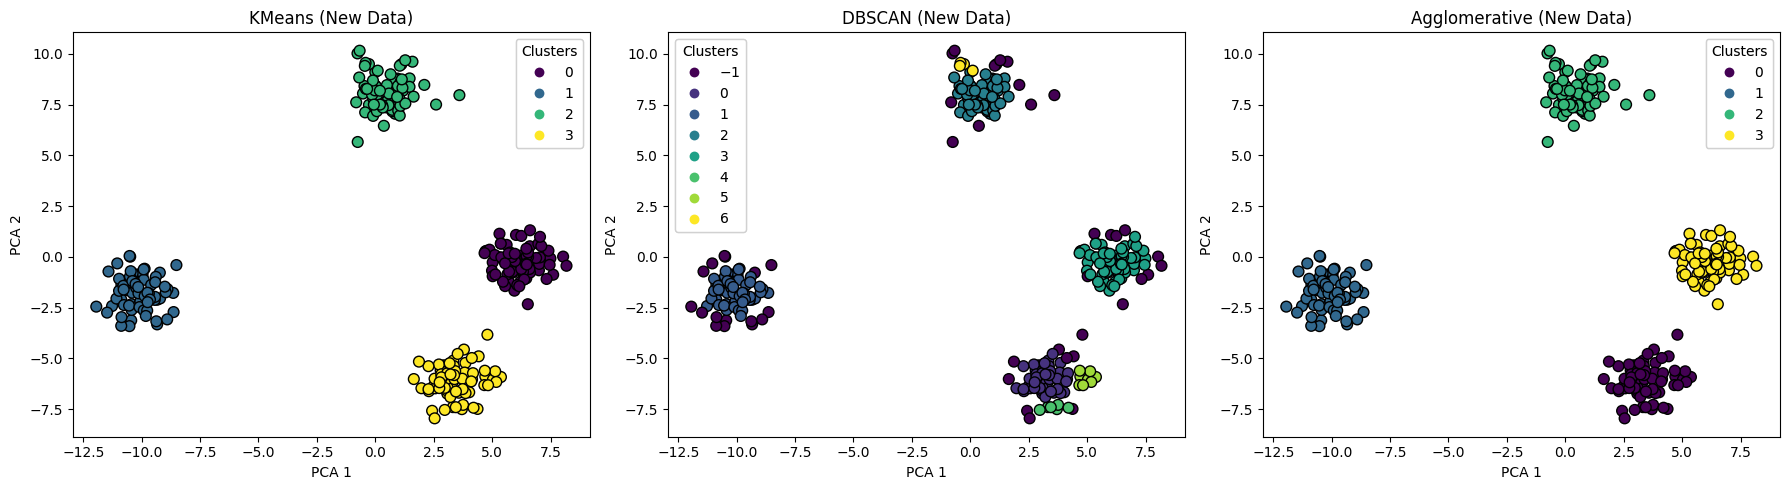

In [20]:
fig_new, axes_new = plt.subplots(1, 3, figsize=(18, 5))
titles_new = ['KMeans (New Data)', 'DBSCAN (New Data)', 'Agglomerative (New Data)']
labels_list_new = [labels_kmeans_new, labels_dbscan_new, labels_agglo_new]

for ax, title, labels in zip(axes_new, titles_new, labels_list_new):
    scatter_new = ax.scatter(vectors_2d_new[:, 0], vectors_2d_new[:, 1], c=labels, cmap='viridis', edgecolor='k', s=60)
    ax.set_title(title)
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    legend_new = ax.legend(*scatter_new.legend_elements(), title="Clusters")
    ax.add_artist(legend_new)

plt.tight_layout()
plt.show()

Finally, let's visualize the silhouette scores for the new dataset to compare the performance of the models.

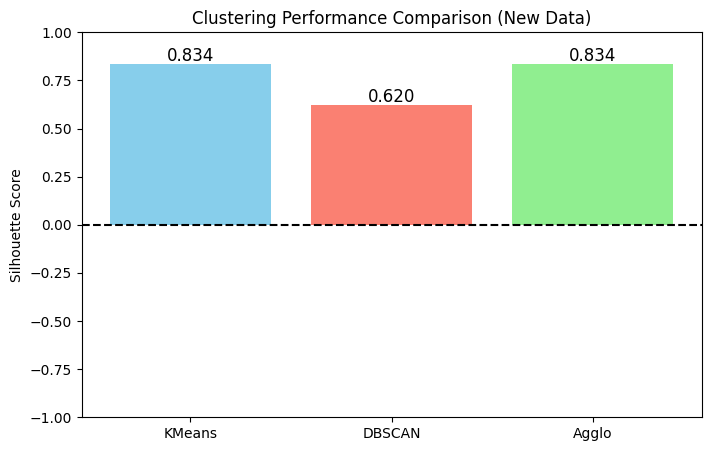

In [21]:
models_new = ['KMeans', 'DBSCAN', 'Agglo']
scores_new = [sil_kmeans_new, sil_dbscan_new, sil_agglo_new]
colors_new = ['skyblue', 'salmon', 'lightgreen']

plt.figure(figsize=(8,5))
bars_new = plt.bar(models_new, scores_new, color=colors_new)
plt.ylim(-1, 1) # Silhouette scores range from -1 to 1
plt.ylabel('Silhouette Score')
plt.title('Clustering Performance Comparison (New Data)')

for bar, score in zip(bars_new, scores_new):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.3f}', ha='center', fontsize=12)

plt.axhline(y=0, color='black', linestyle='--') # Add a line at 0 for reference
plt.show()